# Patch success bbox geometry

Новый геометрический эксперимент по clean bbox до атаки: размер объекта и расстояния от патча до центра, ближнего края и дальнего края объекта.

In [11]:
from pathlib import Path
import sys

_nb_cwd = Path.cwd()
if (_nb_cwd / "new_experiments" / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd / "new_experiments"))
elif (_nb_cwd / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd))
else:
    raise RuntimeError(f"Unexpected cwd={_nb_cwd}; run from repo root or new_experiments")

import importlib
import matplotlib.pyplot as plt
import pandas as pd

from patch_success_analysis.notebook_setup import ensure_new_experiments_cwd, make_celeb_patch_success_experiment
import patch_success_analysis.geometry_metrics as geometry_metrics

geometry_metrics = importlib.reload(geometry_metrics)

max_per_class = 3000  # None = all balanced cached examples.

cwd = ensure_new_experiments_cwd()
attack_config, config, exp = make_celeb_patch_success_experiment()
cache = exp.build_or_load_cache(force=False)
examples = geometry_metrics.select_balanced_examples(cache, max_per_class=max_per_class)

print(f"cwd={cwd}")
print(f"attack cache key={attack_config.cache_key()}")
print(f"attack cache path={attack_config.cache_path}")
print(f"examples={len(examples)} | success={sum(e.success for e in examples)} | fail={sum(not e.success for e in examples)}")


cwd=/Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments
attack cache key=34df6a12b82dd284
attack cache path=new_experiments/outputs/patch_success_analysis/cache/attack_pool_34df6a12b82dd284.pkl
examples=6000 | success=3000 | fail=3000


In [12]:
geometry_df = geometry_metrics.geometry_frame(examples, imgsz=int(config.attack.imgsz))
display(geometry_df.head())
display(geometry_metrics.geometry_summary(geometry_df))
print(f"rows with geometry={len(geometry_df)}")


,path,success,drop,conf_clean,conf_patch,bbox_x1,bbox_y1,bbox_x2,bbox_y2,bbox_width,...,patch_x1,patch_y1,patch_x2,patch_y2,distance_to_object_center,distance_to_object_center_frac,distance_to_nearest_object_edge,distance_to_nearest_object_edge_frac,distance_to_farthest_object_edge,distance_to_farthest_object_edge_frac
0,../datasets/celeb_fbi_640/test_3228.jpg,True,0.325884,0.947674,0.621790,103.716202,38.878479,434.857300,611.543823,331.141098,...,0.0,0.0,160.0,160.0,309.770855,0.484017,0.000000,0.000000,639.110741,0.998611
1,../datasets/celeb_fbi_640/train_2618.jpg,True,0.632715,0.923362,0.290647,209.273376,35.988159,420.407104,617.115967,211.133728,...,0.0,0.0,160.0,160.0,340.496488,0.532026,49.273376,0.076990,635.901375,0.993596
2,../datasets/celeb_fbi_640/train_2903.jpg,True,0.665270,0.907986,0.242716,206.629608,3.226807,438.850800,637.610718,232.221191,...,0.0,0.0,160.0,160.0,341.648925,0.533826,46.629608,0.072859,663.101507,1.036096
3,../datasets/celeb_fbi_640/test_1092.jpg,True,0.911507,0.911507,0.000000,238.316879,95.919556,356.626099,537.532593,118.309219,...,0.0,0.0,160.0,160.0,321.454636,0.502273,78.316879,0.122370,534.656967,0.835402
4,../datasets/celeb_fbi_640/train_43.jpg,True,0.341378,0.922432,0.581054,224.232010,15.698975,436.909607,625.801270,212.677597,...,0.0,0.0,160.0,160.0,347.485757,0.542946,64.232010,0.100363,652.137634,1.018965


bbox_area_frac                               bbox_sqrt_area_frac  \
                 count      mean       std    median               count   
success                                                                    
False             3000  0.297607  0.068503  0.291187                3000   
True              3000  0.282408  0.065927  0.274595                3000   

                                      bbox_width              ...  \
             mean       std    median      count        mean  ...   
success                                                       ...   
False    0.541754  0.064118  0.539617       3000  204.626387  ...   
True     0.527962  0.060544  0.524018       3000  197.371552  ...   

        distance_to_object_center             distance_to_nearest_object_edge  \
                              std      median                           count   
success                                                                         
False                   19.842240  340.890349                            3000   
True                    17.672891  342.208667                            3000   

                                         distance_to_farthest_object_edge  \
              mean        std     median                            count   
success                                                                     
False    58.311722  28.262523  59.963928                             3000   
True     61.144780  26.348917  65.017914                             3000   

                                            
               mean        std      median  
success                                     
False    638.491404  34.641931  641.521432  
True     634.580114  27.649322  636.980725  

[2 rows x 76 columns]

rows with geometry=6000


## Object Size

Основной размер объекта: bbox area fraction (`bbox_area / 640^2`). Слева bar chart mean +/- std, справа все значения: sampled scatter + boxplot.

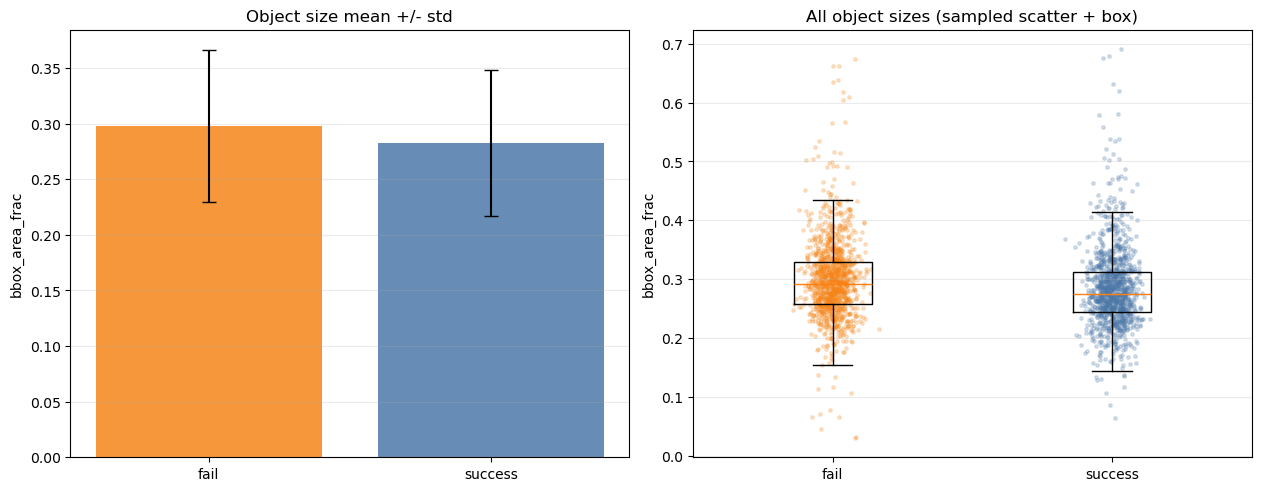

new_experiments/outputs/patch_success_analysis/figures/bbox_object_size_success_fail.png


In [13]:
fig = geometry_metrics.plot_object_size_summary(geometry_df, metric="bbox_area_frac")
object_size_fig_path = exp.figures_dir / "bbox_object_size_success_fail.png"
fig.savefig(object_size_fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(object_size_fig_path)


## Patch-to-Object Distances

Distances are measured in the 640x640 letterboxed coordinate system:

- center: patch center to clean bbox center;
- nearest edge: minimum rectangle-to-rectangle distance, 0 if patch overlaps bbox;
- farthest edge: maximum distance from patch center to clean bbox corners.

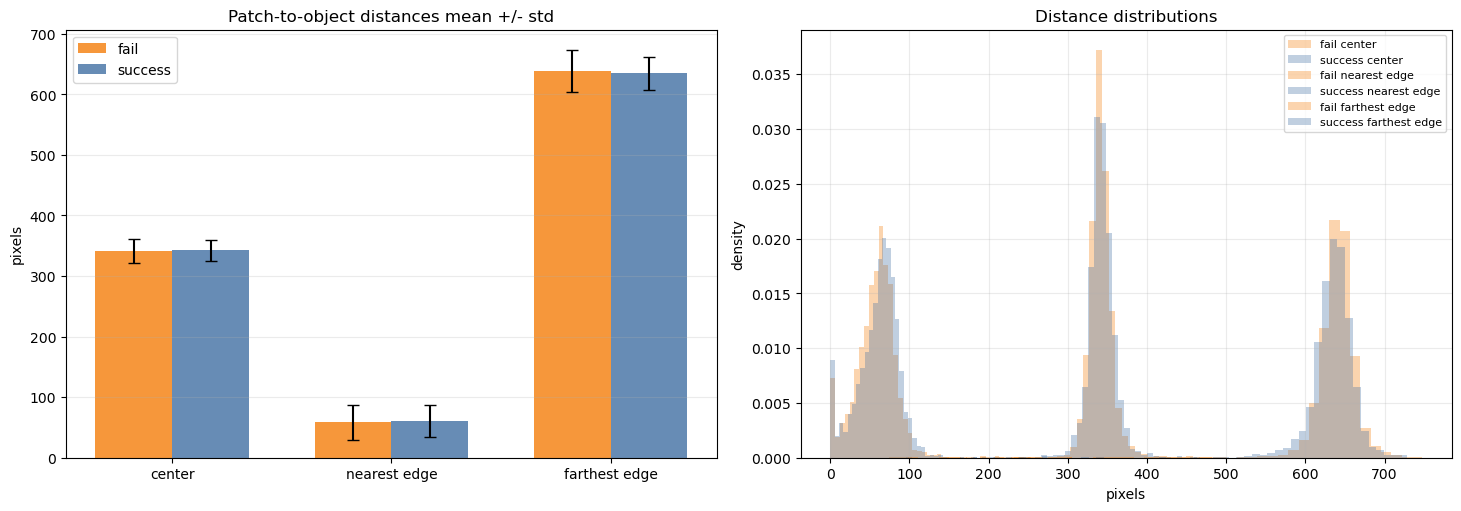

new_experiments/outputs/patch_success_analysis/figures/bbox_patch_object_distances_success_fail.png


In [14]:
fig = geometry_metrics.plot_geometry_distance_summary(geometry_df)
distance_fig_path = exp.figures_dir / "bbox_patch_object_distances_success_fail.png"
fig.savefig(distance_fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(distance_fig_path)


In [15]:
distance_cols = [
    "distance_to_object_center",
    "distance_to_nearest_object_edge",
    "distance_to_farthest_object_edge",
]
display(
    geometry_df.groupby("success")[distance_cols + ["bbox_area_frac", "bbox_sqrt_area_frac"]]
    .agg(["mean", "std", "median"])
    .rename(index={False: "fail", True: "success"})
)


distance_to_object_center                         \
                             mean        std      median   
success                                                    
fail                   341.028972  19.842240  340.890349   
success                342.483795  17.672891  342.208667   

        distance_to_nearest_object_edge                        \
                                   mean        std     median   
success                                                         
fail                          58.311722  28.262523  59.963928   
success                       61.144780  26.348917  65.017914   

        distance_to_farthest_object_edge                         \
                                    mean        std      median   
success                                                           
fail                          638.491404  34.641931  641.521432   
success                       634.580114  27.649322  636.980725   

        bbox_area_frac                     bbox_sqrt_area_frac            \
                  mean       std    median                mean       std   
success                                                                    
fail          0.297607  0.068503  0.291187            0.541754  0.064118   
success       0.282408  0.065927  0.274595            0.527962  0.060544   

                   
           median  
success            
fail     0.539617  
success  0.524018

## Right-Detected Symmetric Gray Padding

Оцениваем влияние серых padding-полос по краям изображения. Основной вариант ниже: детектируем ширину серого столбика **только справа** и переносим эту же ширину на левую сторону. Это использует ожидаемую симметрию letterbox-полей и избегает шума слева.

- `right_gray_padding_area_frac`: доля изображения, занятая right-detected symmetric gray padding;
- `patch_right_gray_padding_overlap_frac`: какая часть патча лежит на этой padding-зоне;
- `object_right_gray_padding_overlap_frac`: какая часть clean bbox лежит на этой padding-зоне;
- `object_distance_to_right_gray_padding`: расстояние bbox до ближайшей такой padding-зоны, 0 если bbox пересекает padding.

Для сравнения старые независимые left/right метрики с префиксом `gray_...` также остаются в `geometry_df` и в quality table.

In [16]:
geometry_metrics = importlib.reload(geometry_metrics)

padding_quality_df = pd.DataFrame(geometry_metrics.padding_metric_quality(geometry_df))
padding_quality_df = padding_quality_df.sort_values(["best_accuracy", "roc_auc"], ascending=False)
display(padding_quality_df)

padding_cols = [
    "right_gray_padding_area_frac",
    "right_gray_pad_x_total",
    "right_gray_pad_y_total",
    "patch_right_gray_padding_overlap_frac",
    "object_right_gray_padding_overlap_frac",
    "object_distance_to_right_gray_padding",
    "gray_padding_area_frac",
    "gray_pad_x_total",
    "patch_gray_padding_overlap_frac",
    "padding_area_frac",
]
display(
    geometry_df.groupby("success")[padding_cols]
    .agg(["mean", "std", "median"])
    .rename(index={False: "fail", True: "success"})
)


,metric,roc_auc,best_accuracy,best_threshold,best_direction
10,patch_gray_padding_overlap_frac,0.233281,0.740333,9.343750e-01,-1
8,gray_pad_x_total,0.228864,0.740167,3.015000e+02,-1
7,gray_padding_area_frac,0.228094,0.740000,4.710937e-01,-1
15,right_gray_pad_x_total,0.229106,0.739833,3.010000e+02,-1
17,patch_right_gray_padding_overlap_frac,0.234016,0.739667,9.406250e-01,-1
14,right_gray_padding_area_frac,0.228347,0.739667,4.703125e-01,-1
12,object_distance_to_gray_padding,0.764267,0.735500,6.714178e+01,1
13,object_distance_to_gray_padding_frac,0.764267,0.735500,1.049090e-01,1
19,object_distance_to_right_gray_padding,0.763570,0.735500,6.532141e+01,1
20,object_distance_to_right_gray_padding_frac,0.763570,0.735500,1.020647e-01,1


right_gray_padding_area_frac                      \
                                mean       std    median   
success                                                    
fail                         0.45142  0.155193  0.503125   
success                      0.31135  0.113197  0.325000   

        right_gray_pad_x_total                    right_gray_pad_y_total  \
                          mean         std median                   mean   
success                                                                    
fail                286.735333  104.208063  322.0               2.175000   
success             196.901333   76.529375  208.0               2.373667   

                          patch_right_gray_padding_overlap_frac  ...  \
               std median                                  mean  ...   
success                                                          ...   
fail     15.874814    0.0                              0.826039  ...   
success  17.686840    0.0                              0.619937  ...   

        gray_padding_area_frac gray_pad_x_total                     \
                        median             mean         std median   
success                                                              
fail                  0.500781       286.218000  104.099763  320.5   
success               0.323437       196.393667   76.458023  207.0   

        patch_gray_padding_overlap_frac                  padding_area_frac  \
                                   mean       std median              mean   
success                                                                      
fail                           0.824752  0.243643   1.00               0.0   
success                        0.616894  0.220986   0.65               0.0   

                     
         std median  
success              
fail     0.0    0.0  
success  0.0    0.0  

[2 rows x 30 columns]

,metric,roc_auc,best_accuracy,best_threshold,best_direction
15,right_gray_pad_x_total,0.229106,0.739833,301.000000,-1
14,right_gray_padding_area_frac,0.228347,0.739667,0.470313,-1
16,right_gray_pad_y_total,0.503405,0.503833,9.000000,1


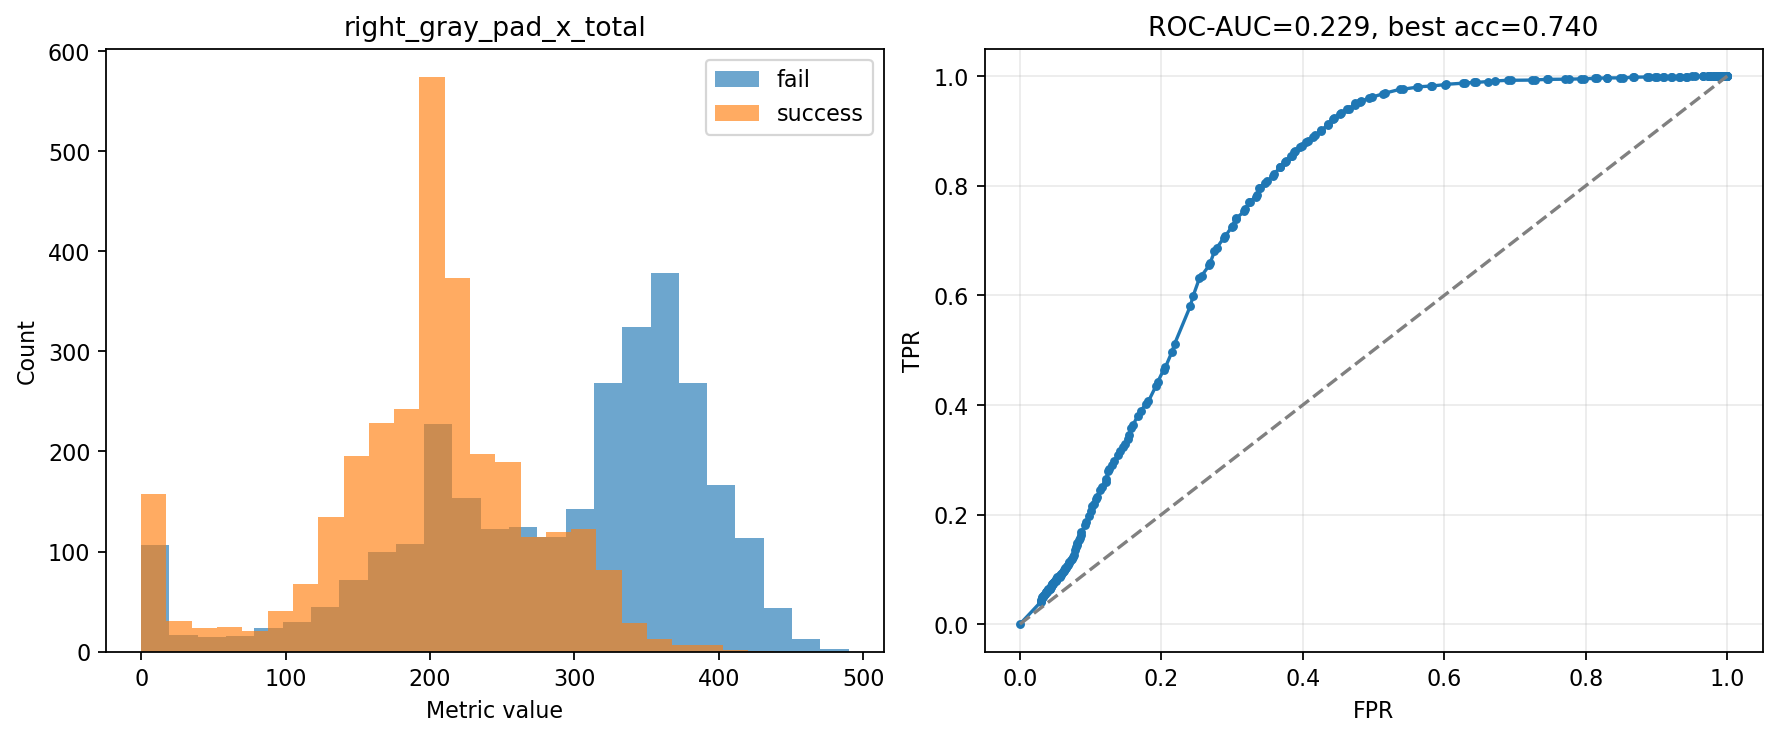

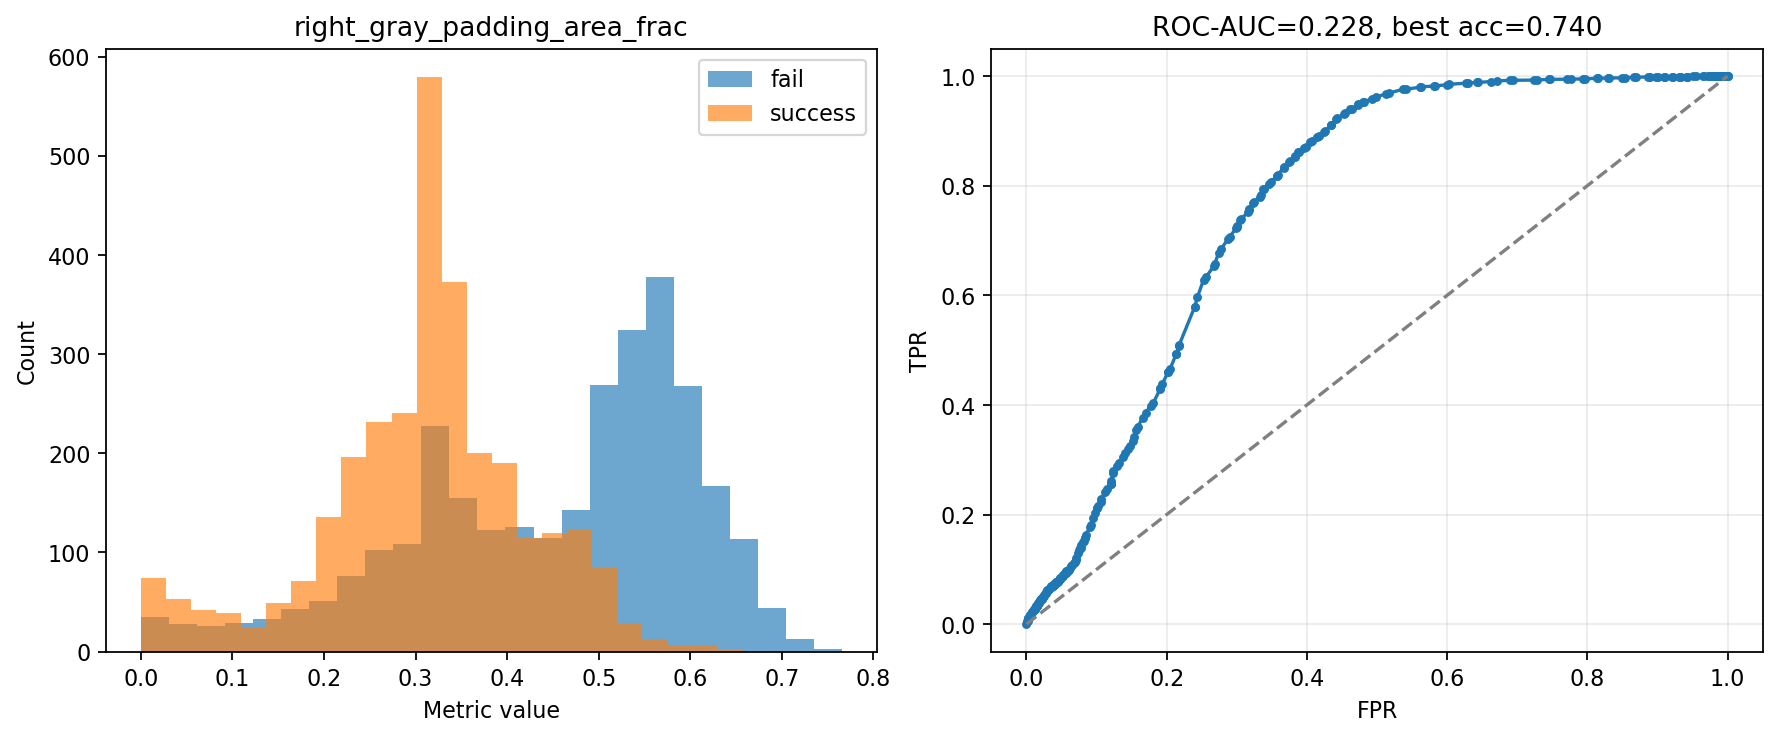

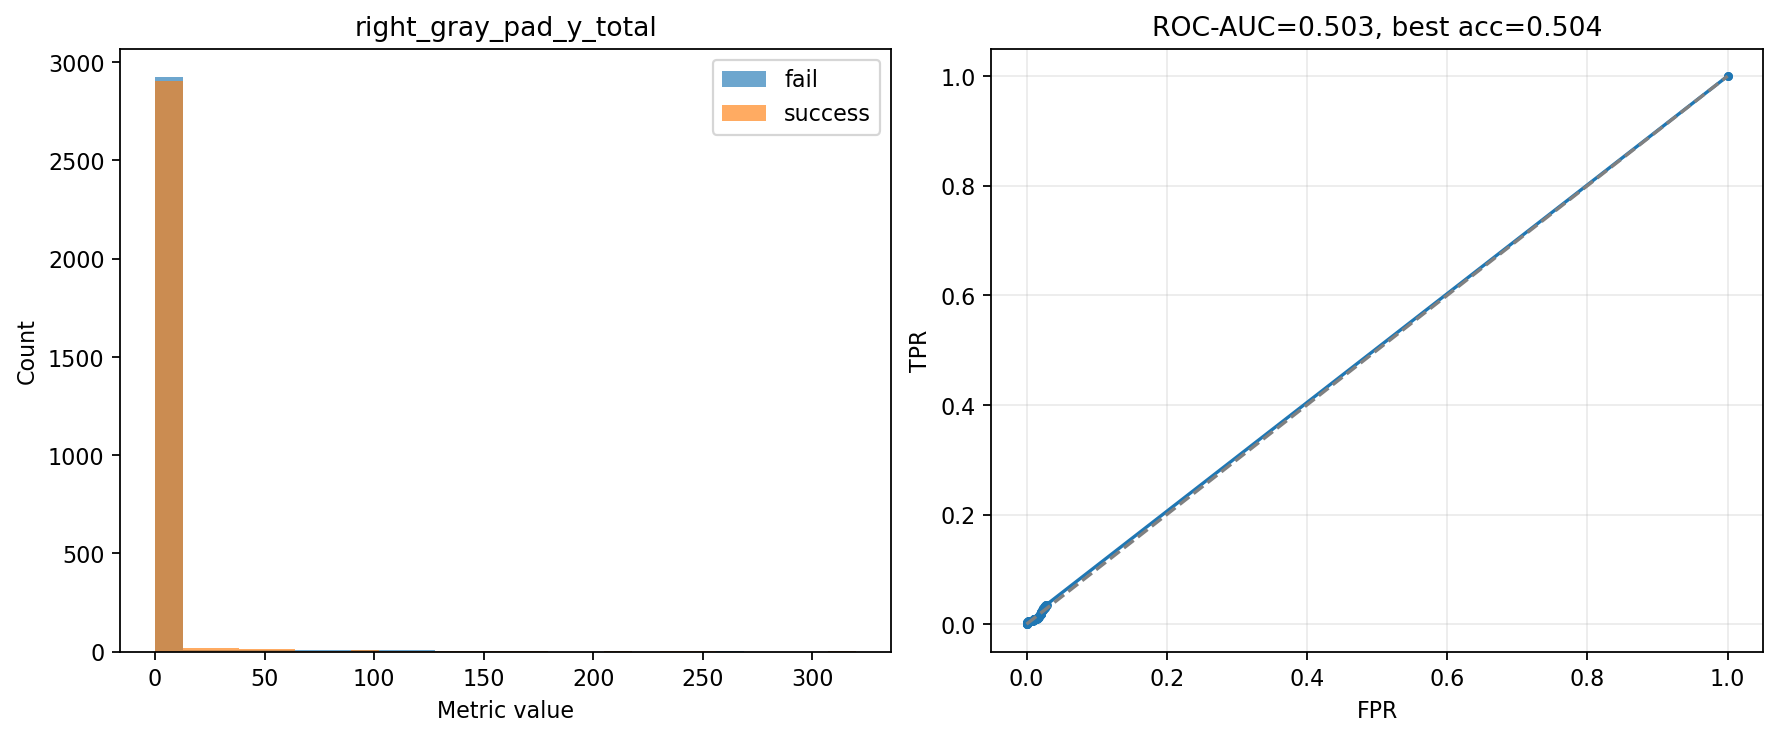

In [17]:
from IPython.display import Image, display
from patch_success_analysis.plots import plot_metric_distribution_and_roc

right_padding_quality = padding_quality_df[
    padding_quality_df["metric"].astype(str).str.startswith("right_")
].sort_values(["best_accuracy", "roc_auc"], ascending=False)
display(right_padding_quality)

padding_metric_figure_paths = []
for _, row in right_padding_quality.iterrows():
    metric = row["metric"]
    values = geometry_df[metric].astype("float64").to_numpy()
    labels = geometry_df["success"].astype(bool).to_numpy()
    fig_path = exp.figures_dir / f"padding_metric_{metric}.png"
    fig = plot_metric_distribution_and_roc(
        labels,
        values,
        metric_name=metric,
        auc=float(row["roc_auc"]),
        best_accuracy=float(row["best_accuracy"]),
        direction=int(row["best_direction"]),
        save_path=fig_path,
    )
    plt.close(fig)
    padding_metric_figure_paths.append(str(fig_path))

for path in padding_metric_figure_paths:
    display(Image(filename=path))


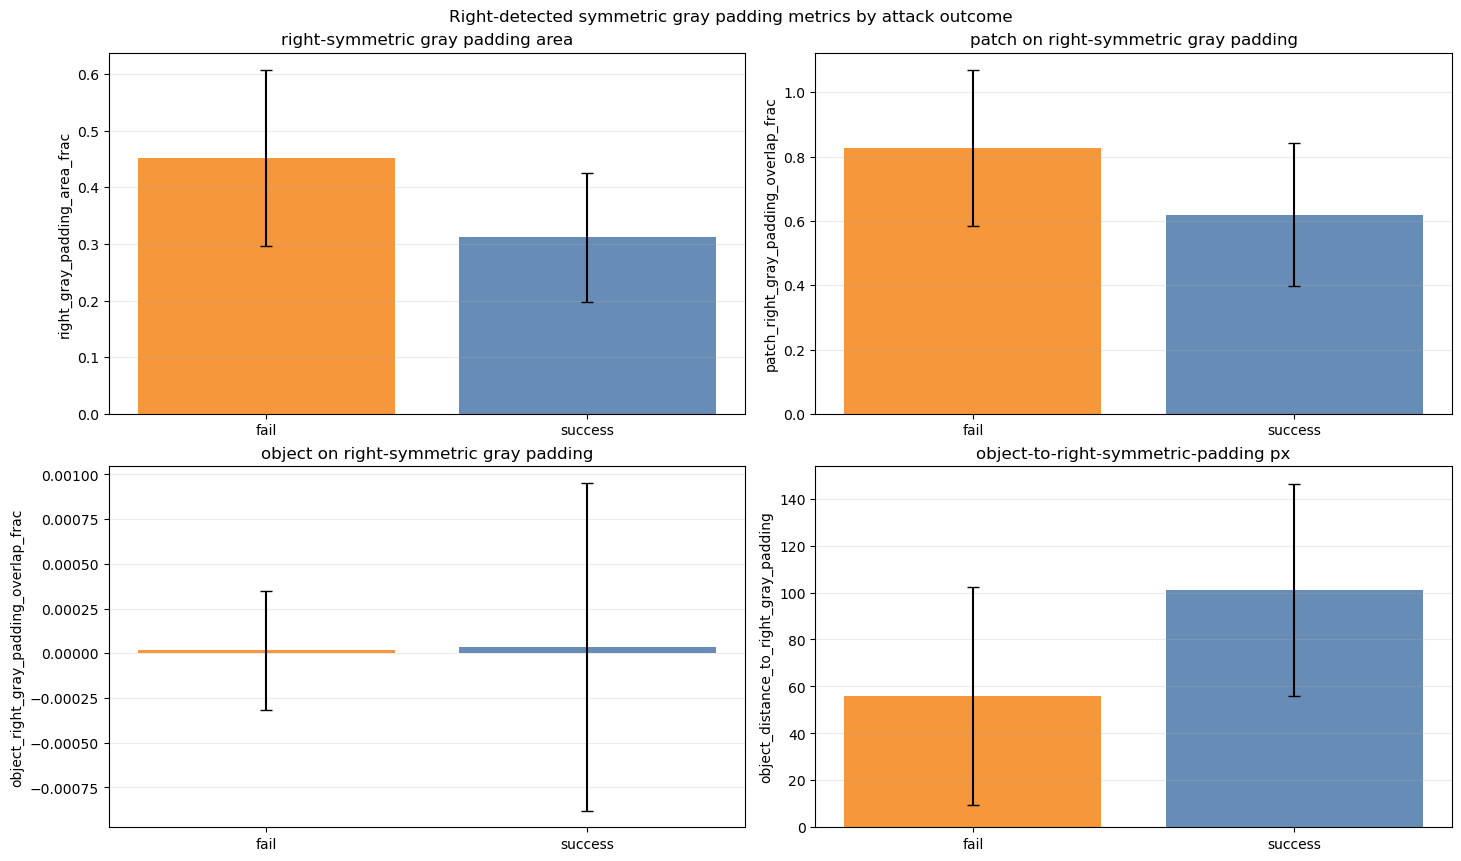

new_experiments/outputs/patch_success_analysis/figures/letterbox_padding_summary_success_fail.png


In [18]:
fig = geometry_metrics.plot_padding_summary(geometry_df)
padding_summary_fig_path = exp.figures_dir / "letterbox_padding_summary_success_fail.png"
fig.savefig(padding_summary_fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(padding_summary_fig_path)


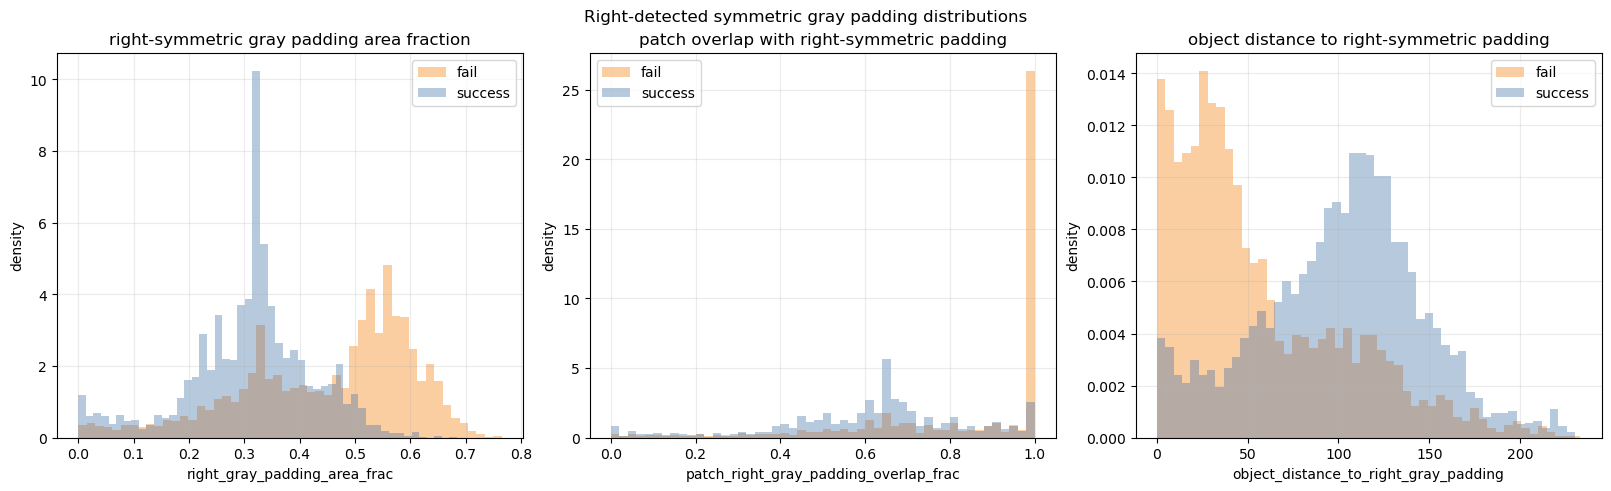

new_experiments/outputs/patch_success_analysis/figures/letterbox_padding_distributions_success_fail.png


In [19]:
fig = geometry_metrics.plot_padding_distributions(geometry_df)
padding_distribution_fig_path = exp.figures_dir / "letterbox_padding_distributions_success_fail.png"
fig.savefig(padding_distribution_fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(padding_distribution_fig_path)


### Average Gray Padding Edges

Визуализация того, где в среднем найдены внутренние края серых вертикальных столбиков. Левая и правая стороны детектируются независимо; таблица ниже показывает mean/std/median и разницу ширин.

gray_pad_left  gray_pad_right  gray_left_inner_edge_x  \
overall mean       120.396667      120.909167              120.396667   
        std         50.859097       50.927676               50.859097   
        median     114.000000      115.000000              114.000000   
fail    mean       142.850333      143.367667              142.850333   
        std         52.011707       52.104031               52.011707   
        median     160.000000      161.000000              160.000000   
success mean        97.943000       98.450667               97.943000   
        std         38.213477       38.264687               38.213477   
        median     104.000000      104.000000              104.000000   

                gray_right_inner_edge_x  gray_left_right_width_diff  
overall mean                 519.090833                   -0.512500  
        std                   50.927676                    1.791195  
        median               525.000000                    0.000000  
fail    mean                 496.632333                   -0.517333  
        std                   52.104031                    1.826147  
        median               479.000000                    0.000000  
success mean                 541.549333                   -0.507667  
        std                   38.264687                    1.755839  
        median               536.000000                    0.000000

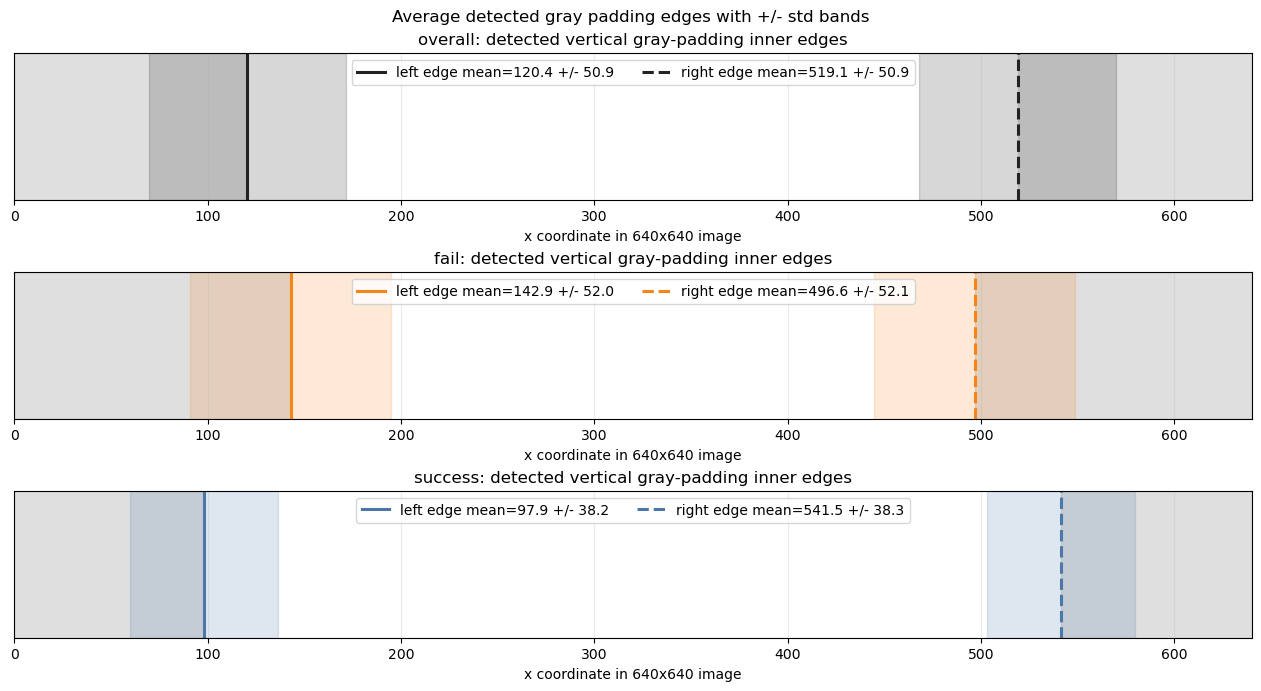

new_experiments/outputs/patch_success_analysis/figures/gray_padding_edges_mean_std.png


In [20]:
geometry_metrics = importlib.reload(geometry_metrics)

display(geometry_metrics.gray_padding_edge_summary(geometry_df, imgsz=int(config.attack.imgsz)))

fig = geometry_metrics.plot_gray_padding_edges_summary(geometry_df, imgsz=int(config.attack.imgsz))
gray_edges_fig_path = exp.figures_dir / "gray_padding_edges_mean_std.png"
fig.savefig(gray_edges_fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(gray_edges_fig_path)


# Вывод

Одним из ключевых параметров в успешности атак является паддинг, который на эксперименты влиять не должен. Ввиду этого было решено сменить датасет и провести эксперименты этой и прошлой недель заново.